In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 545
Number of columns: 13

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


## 2. Data Quality Report

A data quality report is created to identify missing values, duplicate records, incorrect data types, and unusual value ranges before cleaning the dataset.

In [4]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Null_Count": df.isnull().sum().values,
    "Unique_Values": df.nunique().values
})

quality_report

,Column,Data_Type,Null_Count,Unique_Values
0,price,int64,0,219
1,area,int64,0,284
2,bedrooms,int64,0,6
3,bathrooms,int64,0,4
4,stories,int64,0,4
5,mainroad,str,0,2
6,guestroom,str,0,2
7,basement,str,0,2
8,hotwaterheating,str,0,2
9,airconditioning,str,0,2


In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


### Missing Data Decision

The dataset contains no missing values in any column. Therefore, mean, median, mode, forward-fill, or row-deletion techniques are not required.

No artificial missing values will be introduced because the purpose of data cleaning is to accurately document and improve the existing dataset.

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [7]:
df_cleaned = df.drop_duplicates().copy()

print("Rows before removing duplicates:", len(df))
print("Rows after removing duplicates:", len(df_cleaned))
print("Duplicates removed:", len(df) - len(df_cleaned))

Rows before removing duplicates: 545
Rows after removing duplicates: 545
Duplicates removed: 0


### Duplicate Removal Decision

No duplicate rows were found in the dataset. Therefore, removing duplicates did not change the number of records.

The `drop_duplicates()` operation was still applied as a standard data-cleaning step.

In [8]:
categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

for column in categorical_columns:
    print("\n", column)
    print(df_cleaned[column].unique())


 mainroad
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

 guestroom
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

 basement
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

 hotwaterheating
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

 airconditioning
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

 prefarea
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

 furnishingstatus
<ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


In [9]:
binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for column in binary_columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "y": "yes",
            "n": "no",
            "m": "male",
            "f": "female"
        })
    )

df_cleaned["furnishingstatus"] = (
    df_cleaned["furnishingstatus"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_cleaned.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Standardisation Decision

Categorical columns were standardised by removing unnecessary spaces and converting text to lowercase. Binary values were kept in a consistent `yes`/`no` format, while furnishing status was standardised to lowercase text.

The dataset was already largely consistent, so this process did not substantially change the existing values.

In [10]:
numeric_columns = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

df_cleaned[numeric_columns].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [11]:
for column in numeric_columns:
    print(
        column,
        "Min =", df_cleaned[column].min(),
        "| Max =", df_cleaned[column].max()
    )

price Min = 1750000 | Max = 13300000
area Min = 1650 | Max = 16200
bedrooms Min = 1 | Max = 6
bathrooms Min = 1 | Max = 4
stories Min = 1 | Max = 4
parking Min = 0 | Max = 3


In [12]:
print("Invalid price:", (df_cleaned["price"] <= 0).sum())
print("Invalid area:", (df_cleaned["area"] <= 0).sum())
print("Invalid bedrooms:", (df_cleaned["bedrooms"] <= 0).sum())
print("Invalid bathrooms:", (df_cleaned["bathrooms"] <= 0).sum())
print("Invalid stories:", (df_cleaned["stories"] <= 0).sum())
print("Invalid parking:", (df_cleaned["parking"] < 0).sum())

Invalid price: 0
Invalid area: 0
Invalid bedrooms: 0
Invalid bathrooms: 0
Invalid stories: 0
Invalid parking: 0


### Value Range Decision

The numerical columns were checked for logically invalid values. Price and area must be positive, while bedrooms, bathrooms, and stories must not be zero or negative. Parking cannot be negative.

No logically invalid values were identified in the dataset.

## 3. Outlier Detection

The Interquartile Range (IQR) method is used to identify potential outliers in numerical columns.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside these boundaries are considered potential outliers.

In [13]:
outlier_summary = []

for column in numeric_columns:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_cleaned[
        (df_cleaned[column] < lower_bound) |
        (df_cleaned[column] > upper_bound)
    ]
    
    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,price,3430000.0,5740000.0,2310000.0,-35000.0,9205000.0,15
1,area,3600.0,6360.0,2760.0,-540.0,10500.0,12
2,bedrooms,2.0,3.0,1.0,0.5,4.5,12
3,bathrooms,1.0,2.0,1.0,-0.5,3.5,1
4,stories,1.0,2.0,1.0,-0.5,3.5,41
5,parking,0.0,1.0,1.0,-1.5,2.5,12


In [14]:
import matplotlib.pyplot as plt

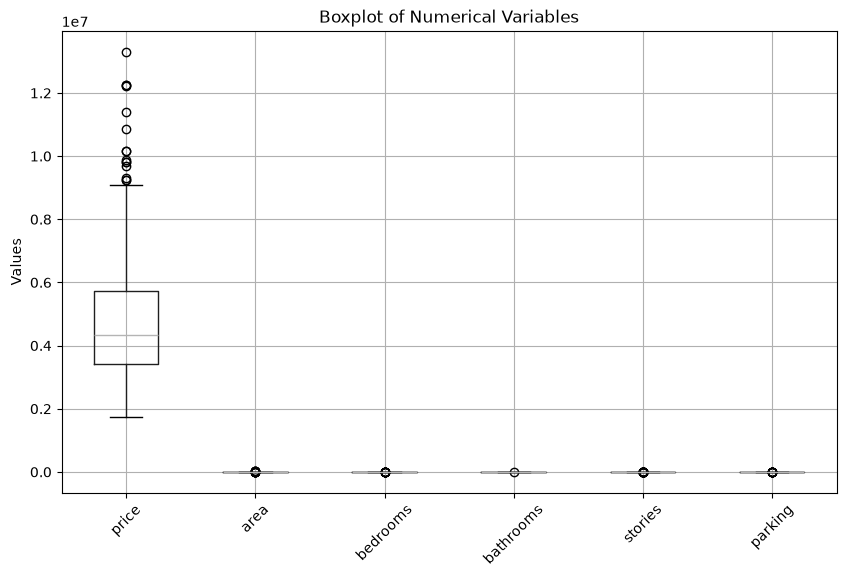

In [15]:
plt.figure(figsize=(10, 6))

df_cleaned[numeric_columns].boxplot()

plt.title("Boxplot of Numerical Variables")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.show()

### Outlier Decision

The IQR method identifies statistical outliers in some numerical variables. However, an IQR outlier is not automatically an incorrect record.

In a housing dataset, unusually expensive houses or properties with very large areas may represent genuine properties rather than data-entry errors.

Therefore, potential outliers are retained unless they are confirmed to be invalid. Removing legitimate high-value properties could distort the analysis.

In [16]:
for column in numeric_columns:
    df_cleaned[column] = pd.to_numeric(
        df_cleaned[column],
        errors="coerce"
    )

for column in categorical_columns:
    df_cleaned[column] = df_cleaned[column].astype("string")

df_cleaned.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            string
guestroom           string
basement            string
hotwaterheating     string
airconditioning     string
parking              int64
prefarea            string
furnishingstatus    string
dtype: object

### Data Type Correction Decision

Numerical variables were converted to numeric data types to ensure that mathematical and statistical operations can be performed correctly.

Categorical variables were converted to string data types because they represent descriptive categories rather than continuous numerical measurements.

In [17]:
before_nulls = df.isnull().sum().sum()
after_nulls = df_cleaned.isnull().sum().sum()

before_duplicates = df.duplicated().sum()
after_duplicates = df_cleaned.duplicated().sum()

before_rows = len(df)
after_rows = len(df_cleaned)

before_dtype_accuracy = "Verified"
after_dtype_accuracy = "Verified"

comparison = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Total Null Values",
        "Duplicate Rows",
        "Dtype Accuracy"
    ],
    "Before Cleaning": [
        before_rows,
        before_nulls,
        before_duplicates,
        before_dtype_accuracy
    ],
    "After Cleaning": [
        after_rows,
        after_nulls,
        after_duplicates,
        after_dtype_accuracy
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Row Count,545,545
1,Total Null Values,0,0
2,Duplicate Rows,0,0
3,Dtype Accuracy,Verified,Verified


In [18]:
print("Final Dataset Shape:", df_cleaned.shape)

print("\nMissing Values:")
print(df_cleaned.isnull().sum())

print("\nDuplicate Rows:")
print(df_cleaned.duplicated().sum())

print("\nData Types:")
print(df_cleaned.dtypes)

Final Dataset Shape: (545, 13)

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Rows:
0

Data Types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            string
guestroom           string
basement            string
hotwaterheating     string
airconditioning     string
parking              int64
prefarea            string
furnishingstatus    string
dtype: object


In [19]:
df_cleaned.to_csv("Housing_cleaned.csv", index=False)

print("Cleaned dataset saved successfully as Housing_cleaned.csv")

Cleaned dataset saved successfully as Housing_cleaned.csv


In [20]:
df_cleaned.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [21]:
df_cleaned.shape

(545, 13)

## 4. Conclusion

The Housing dataset was systematically inspected and cleaned using Python and pandas.

The data quality assessment showed that the dataset contained 545 rows and 13 columns. No missing values or duplicate records were identified, so no imputation or duplicate deletion was required.

Categorical values were standardised by removing unnecessary spaces and converting text to a consistent lowercase format. Numerical columns were checked for invalid ranges and converted to appropriate numeric data types.

Potential numerical outliers were identified using the IQR method. These values were reviewed as potential observations rather than automatically removed because unusually expensive properties or properties with large areas can represent genuine housing records.

Finally, the cleaned dataset was validated and saved as `Housing_cleaned.csv`.

The resulting dataset is ready for further analysis and machine-learning applications.